# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


In [56]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [57]:
# Read in the data set
ames_df = pd.read_csv("ames.csv")
ames_df.head()

,Year_Built,Year_Remod_Add,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Full_Bath,Half_Bath,Bedroom_AbvGr,Kitchen_AbvGr,TotRms_AbvGrd,Fireplaces,Garage_Area,Sale_Price
0,1960,1960,1080,1656,0,1656,1,0,3,1,7,2,528,215000
1,1961,1961,882,896,0,896,1,0,2,1,5,0,730,105000
2,1958,1958,1329,1329,0,1329,1,1,3,1,6,0,312,172000
3,1968,1968,2110,2110,0,2110,2,1,3,1,8,2,522,244000
4,1997,1998,928,928,701,1629,2,1,3,1,6,1,482,189900


In [58]:
print("\n------ INFORMATION ------")
ames_df.info()

print("\n------ DATA DESCRIPTION ------")
ames_df.describe()

print("\n------ MISSING VALUES ------")
ames_df.isnull().sum()


------ INFORMATION ------
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Year_Built      2930 non-null   int64
 1   Year_Remod_Add  2930 non-null   int64
 2   Total_Bsmt_SF   2930 non-null   int64
 3   First_Flr_SF    2930 non-null   int64
 4   Second_Flr_SF   2930 non-null   int64
 5   Gr_Liv_Area     2930 non-null   int64
 6   Full_Bath       2930 non-null   int64
 7   Half_Bath       2930 non-null   int64
 8   Bedroom_AbvGr   2930 non-null   int64
 9   Kitchen_AbvGr   2930 non-null   int64
 10  TotRms_AbvGrd   2930 non-null   int64
 11  Fireplaces      2930 non-null   int64
 12  Garage_Area     2930 non-null   int64
 13  Sale_Price      2930 non-null   int64
dtypes: int64(14)
memory usage: 320.6 KB

------ DATA DESCRIPTION ------

------ MISSING VALUES ------


Year_Built        0
Year_Remod_Add    0
Total_Bsmt_SF     0
First_Flr_SF      0
Second_Flr_SF     0
Gr_Liv_Area       0
Full_Bath         0
Half_Bath         0
Bedroom_AbvGr     0
Kitchen_AbvGr     0
TotRms_AbvGrd     0
Fireplaces        0
Garage_Area       0
Sale_Price        0
dtype: int64

In [59]:
# Clean and pre-process the data if neccessary
ames_df = ames_df.drop_duplicates()

#### Dependent variable visualisation

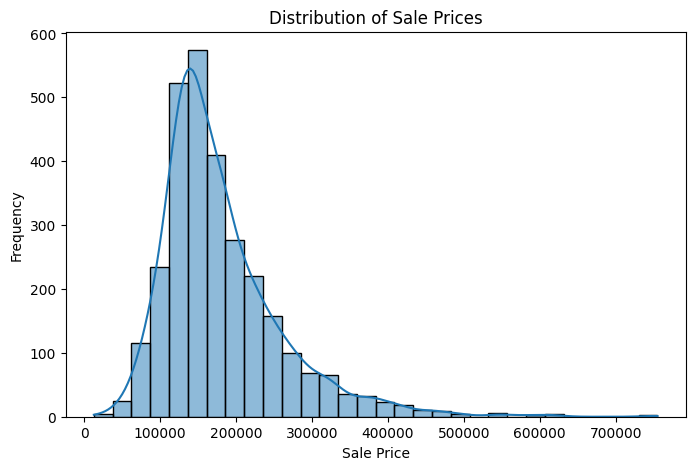

In [60]:
# Explore the data with visualisations such as histograms and correlation matrices

plt.figure(figsize=(8,5))
sns.histplot(ames_df["Sale_Price"], bins= 30, kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

The histogram shows the distribution of house sale prices.
The graph is rightly skewed, indicating some high-value outliers. Based on the graph the highest properties fall between 1200000 - 1800000, while others fall within mid-price range.

#### Independent variable visualisation

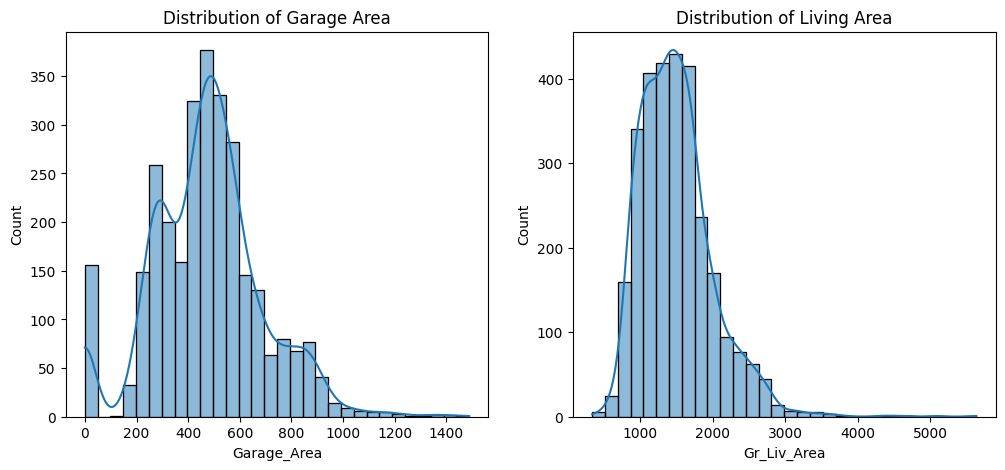

In [61]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(ames_df["Garage_Area"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Garage Area")

sns.histplot(ames_df["Gr_Liv_Area"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Living Area")

plt.show()

The Garage Area indicates the different garage sizes amongst properties in the dataset.

The Living Area indicates the different living room sizes amongst properties in the dataset.

In [62]:
# independent variable
X = ames_df[["Gr_Liv_Area", "Garage_Area"]]

# dependent variable
y = ames_df["Sale_Price"]

Text(0.5, 1.0, 'Garage Area vs Sale Price')

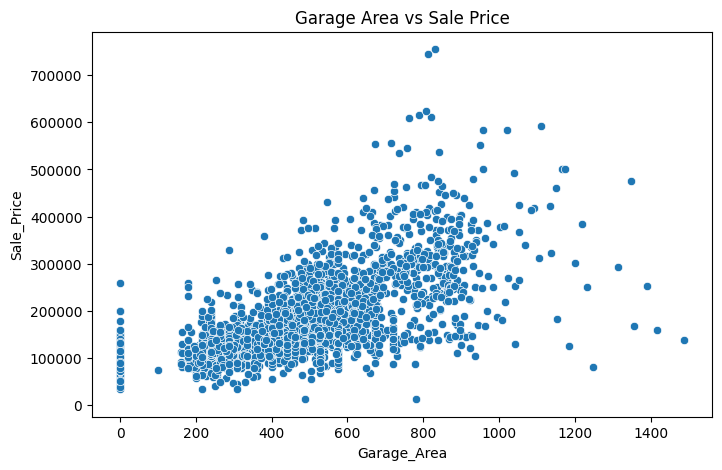

In [63]:
# Displays the relationships between the independent and dependent variables

plt.figure(figsize=(8,5))
sns.scatterplot(x=ames_df["Garage_Area"], y=ames_df["Sale_Price"])
plt.title("Garage Area vs Sale Price")

The scatterplot shows a positive correlation between the sale price and the garage area. This indicates that larger garage areas tend to increase the property value.

Text(0.5, 1.0, 'Living Area vs Sale Price')

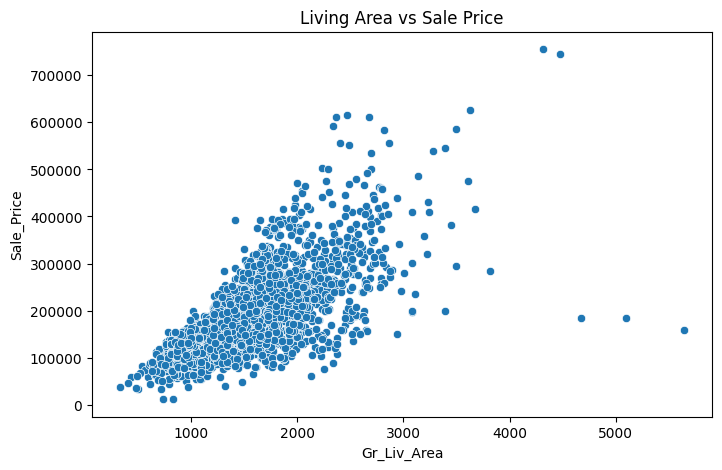

In [64]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=ames_df["Gr_Liv_Area"], y=ames_df["Sale_Price"])
plt.title("Living Area vs Sale Price")

The scatterplot shows a positive correlation between the sale price and the living area. This indicates that larger living areas tend to increase the property value.

In [65]:
# Create a training and test set with a 75:25 split ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [66]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
# Print the trained model's intercept and coefficients

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -5136.460820642591
Coefficients: [ 76.72545865 147.68608993]


The intercept represents the predicted house price when both the garage area and living area are 0.

The coefficient represents how much the sale price changes for each unit increase in the predictor.

In [68]:
# Generate predictions for the test set

predictions = model.predict(X_test)

In [73]:
# calculates and displays the MSE and RMSE
MSE = mean_squared_error(y_test, predictions)
RMSE = np.sqrt(MSE)

print("Mean Squared Error:", MSE)
print("Root Mean Squared Error:", RMSE)

"""
Mean Squared Error in Python 
https://www.geeksforgeeks.org/python/python-mean-squared-error/
"""

Mean Squared Error: 2506587335.7638817
Root Mean Squared Error: 50065.830021721216


'\nMean Squared Error in Python \nhttps://www.geeksforgeeks.org/python/python-mean-squared-error/\n'

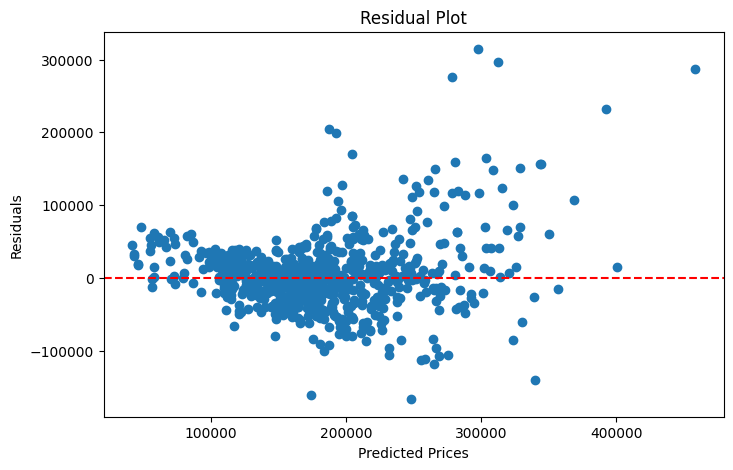

In [70]:
# Displays the differences between the predicted and actual values in the test set.

residuals = y_test - predictions

plt.figure(figsize=(8,5))
plt.scatter(predictions, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.show()


The plot above shows the difference between the predicted prices and the actual prices. 

However, the spread of residuals increases slightly for higher predicted prices, suggesting that the model becomes less accurate for more expensive houses. The presence of a few large residuals also indicates that the model does not perfectly predict some observations.

Overall, the model captures the general trend in the data, but incorporating additional features could improve prediction accuracy.


In [72]:
# prints the coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

"""
Vinod Chugani - Interpreting Coefficients in Linear Regression Models 
https://machinelearningmastery.com/interpreting-coefficients-in-linear-regression-models/
"""

'\nVinod Chugani - Interpreting Coefficients in Linear Regression Models \nhttps://machinelearningmastery.com/interpreting-coefficients-in-linear-regression-models/\n'

**Interpretation of coefficients:**

The coefficient for Gr_Liv_Area indicates that the predicted price for a house, will increase if the living area increases by one unit, provided that the other variables remain constant. 
If the coefficient is 76.73, it means that each additonal square foot of living space increases the predicted sale price by 76.73.

The coefficient for Garage_Area indicates that the predicted price for a house, will increase if the garage area increases by one unit, provided that the other variables remain constant. 
If the coefficient is 147.69, it means that each additonal square foot of garage space increases the predicted sale price by 147.69.

Comparing the coefficients suggests that garage area has a larger impact on the predicted house price per square foot than living area in this model. This indicates that increases in garage size may contribute more strongly to house price predictions than increases in living space, based on the variables included in this analysis.

### Summary of findings

***Exploratory Data Analysis***

The analysis shows that the price of houses increase with both the garage size and the living area size. The scatter plots show a positive correlations between these variables and the sale price.

***Model Performance***

The multiple linear regression model was trained using garage area and living area as predictors of house price. The RMSE measures the average difference between the predicted house price and the actual house price. 

***Notable Observations***

Houses with larger living areas seem to have a greater impact on the sale price compared to houses with larger garages. This could mean that the size of the house is a key factor in determining the value of a property.